# **Color Spaces in OpenCV**

## **Learning Objectives**

By the end of this notebook, you will be able to:

- Understand what a color space is.
- Explain why computers need different color representations.
- Distinguish between BGR, RGB, Grayscale, HSV, and RGBA.
- Convert images between color spaces using OpenCV.
- Choose the appropriate color space for different computer vision tasks.

## **Prerequisites**

Before reading this notebook, you should understand:

- Digital images
- Pixels
- NumPy arrays
- Image channels
- Reading and displaying images with OpenCV

## **What is a Color Space?**

A *color space* is a mathematical model used to represent colors as numerical values.

Since computers cannot perceive colors like humans, every color is stored as one or more numbers. A color space defines what those numbers mean.

Different color spaces are designed for different purposes. Some are better for displaying images, while others simplify image processing or make it easier to detect specific colors.



## **Why do we need different color spaces?**

Humans recognize colors intuitively, but computers only process numbers.

The same image can be represented using different sets of numbers depending on the task.

For example:

- A photo displayed on a screen is commonly represented using (`RGB`).
- OpenCV loads color images using (`BGR`).
- Edge detection often works better on grayscale images.
- Color-based object detection is typically easier in HSV.

## **4. Most common color spaces**

### **4.1 BGR Color Space**

(`BGR`) is the default color space used by OpenCV.

Each pixel consists of three values:

- Blue
- Green
- Red

Each channel ranges from 0 to 255.

A color image is stored as

(height, width, 3)

In [1]:
import numpy as np
import cv2

image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\vision-s-01\pic\001.jpg")
b, g, r = image[20, 50]

print(image.shape)
print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: {image.shape[2]}")
print("Blue:", b)
print("Green:", g)
print("Red:", r)

(1333, 2000, 3)
Height: 1333, Width: 2000, Channels: 3
Blue: 184
Green: 142
Red: 100


### **What happens under the hood?**

OpenCV stores each pixel as three consecutive bytes:

[B, G, R]

For example,

[255, 0, 0]

means

Blue = 255

Green = 0

Red = 0

Therefore the pixel appears blue.

### **4.2 RGB Color Space**

(`RGB`) stores colors using:

- Red
- Green
- Blue

Unlike OpenCV, most visualization libraries such as Matplotlib expect RGB images and if you read an image in opencv, but want to represent it in matplotlib you should convert the color space from (`BGR`) to (`RGB`).

In [2]:
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

r, g, b = rgb_image[20, 50]

print(image.shape)
print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: {image.shape[2]}")
print("Red:", r)
print("Green:", g)
print("Blue:", b)

(1333, 2000, 3)
Height: 1333, Width: 2000, Channels: 3
Red: 100
Green: 142
Blue: 184


The `cv2.COLOR_BGR2RGB` provides a constant that tells the opencv which algorithm should be used for converting color space.

We can change the color space from (`BGR`) to (`RGB`) manually as well, using slicing and indexing and changing the place of `R` and `B`.

In [3]:
# rgb_image = image[..., ::-1]

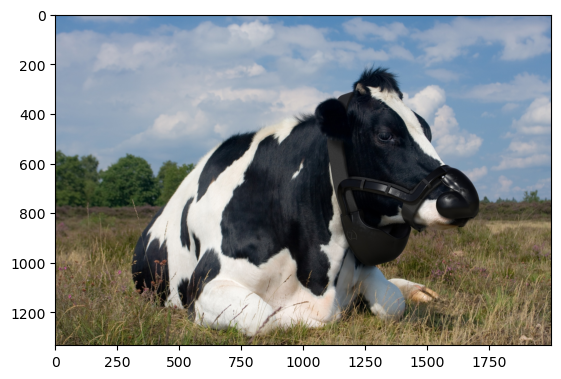

In [4]:
import matplotlib.pyplot as plt

plt.imshow(rgb_image)
plt.show()

### **4.3 Grayscale Color Space**

A grayscale image contains only one channel.

Each pixel represents brightness rather than color.

0 represents black.

255 represents white.

Intermediate values represent different shades of gray.

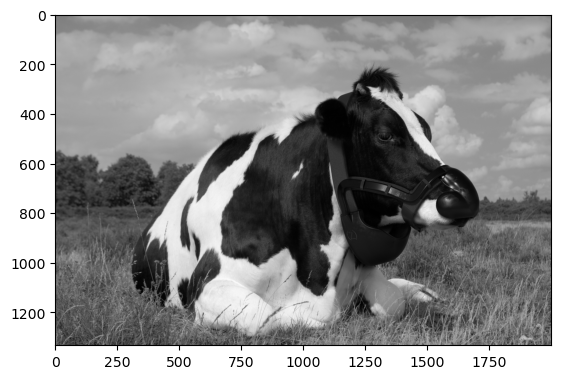

In [5]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap="gray")
plt.show()

In [14]:
gray_image.shape

(1333, 2000)

### **4.4 HSV Color Space**

The HSV (Hue, Saturation, Value) color space represents colors in a way that closely resembles human color perception. Unlike the BGR color space, which defines a color by the intensities of its Blue, Green, and Red components, HSV separates a color into its (`hue`), (`saturation`), and (`brightness`). This separation makes many computer vision tasks, such as color detection and object segmentation, more reliable under varying lighting conditions.

An HSV image consists of three channels:

* Hue (H): Represents *the actual color* (red, green, blue, etc.). In OpenCV, Hue ranges from (`0 to 179`), where each value corresponds to a specific color on the color wheel. OpenCV uses this range instead of 0–360 degrees because images are stored using 8-bit (uint8) values.
* Saturation (S): Represents the *purity* or *intensity* of the color and ranges from (`0 to 255`). A value of 0 produces shades of gray, while 255 represents the most vivid version of the color.
* Value (V): Represents the *brightness* of the color and ranges from (`0 to 255`). A value of 0 corresponds to black, whereas 255 represents the brightest appearance of the color.

HSV is widely used in computer vision because it separates color information (Hue) from brightness (Value), allowing algorithms to detect colors more accurately even when the illumination changes.

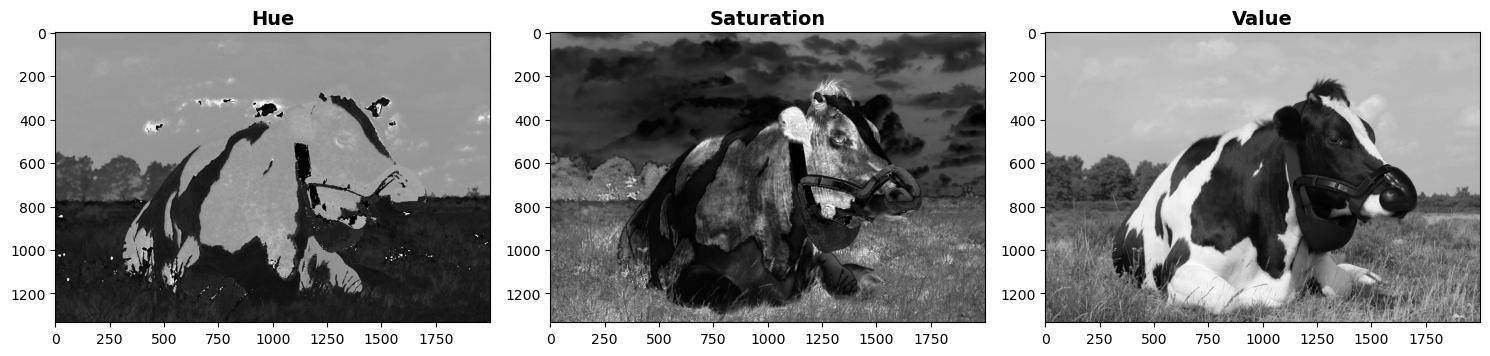

In [6]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

hue, saturation, value = cv2.split(hsv_image)

channels = [hue, saturation, value]
titles = ["Hue", "Saturation", "Value"]

fig, axes = plt.subplots(figsize=(15, 5), nrows=1, ncols=3)

for i, (channel, title) in enumerate(zip(channels, titles)):
    axes[i].imshow(channel, cmap="gray")
    axes[i].set_title(title, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### **Displaying HSV Images with Matplotlib**

An **HSV image is not intended to be viewed directly**. Instead, it is a color representation designed for **image processing tasks**, such as color segmentation, object detection, and image enhancement.

Although an HSV image **can be displayed** using `matplotlib.pyplot.imshow()`, it **will not appear correctly**. This is because Matplotlib assumes that every 3-channel image is in **RGB** format, while an HSV image stores **Hue**, **Saturation**, and **Value** instead of **Red**, **Green**, and **Blue**.

As a result, Matplotlib interprets:

| Actual HSV Channel | Matplotlib Assumes |
|--------------------|--------------------|
| Hue (H)            | Red (R)            |
| Saturation (S)     | Green (G)          |
| Value (V)          | Blue (B)           |

This incorrect interpretation produces a false-color image that does **not** represent the original scene.

To visualize the image correctly, first convert it back to RGB:

```python
rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
plt.imshow(rgb)
```

If the goal is to inspect the HSV data itself (e.g., to analyze hue, saturation, or brightness), it is common to display the **Hue**, **Saturation**, and **Value** channels separately as grayscale images.

### **BGRA Color Space**

The BGRA (Blue, Green, Red, Alpha) color space is an extension of the BGR color space that includes an additional Alpha channel. The Blue, Green, and Red channels define the pixel’s color, while the Alpha channel controls its transparency.

A BGRA image contains four channels:

* Blue (B): Intensity of the blue component (0–255).
* Green (G): Intensity of the green component (0–255).
* Red (R): Intensity of the red component (0–255).
* Alpha (A): Transparency of the pixel (0–255).

The Alpha channel has the following meaning:

* 0 → Fully transparent (completely invisible).
* 255 → Fully opaque (completely visible).
* Values between 0 and 255 represent different levels of transparency.

Unlike the Blue, Green, and Red channels, the Alpha channel does not affect the color itself. Instead, it determines how visible that color is when the image is displayed or composited over another image. BGRA images are commonly used in PNG files, logos, icons, and graphical user interfaces where transparent backgrounds are required.

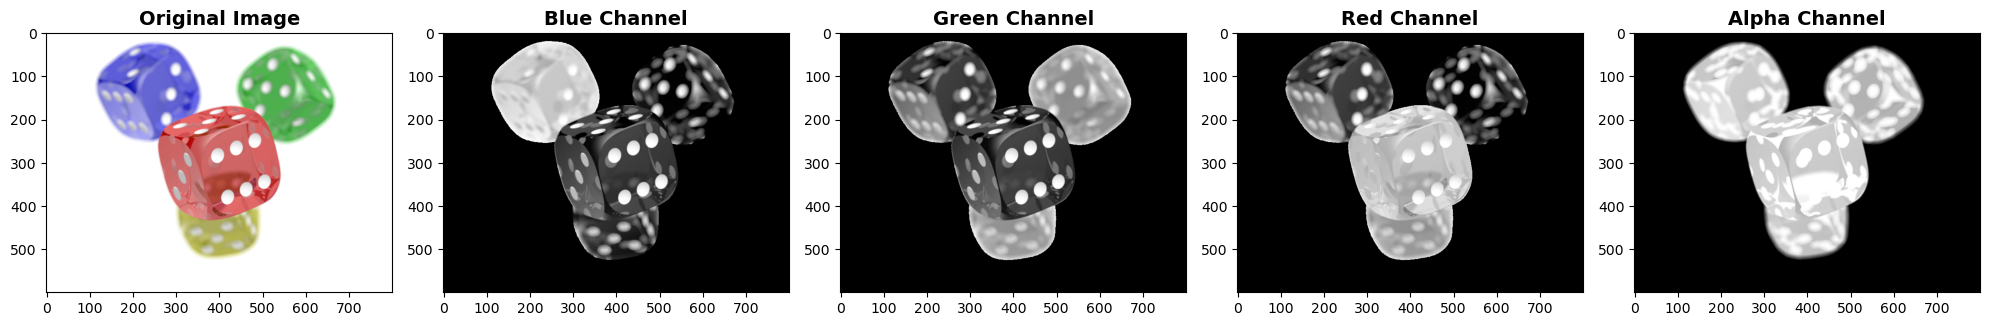

In [13]:
bgra_image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\vision-s-01\pic\transparency.png", cv2.IMREAD_UNCHANGED)

b, g, r, alpha = cv2.split(bgra_image)
rgba_image = cv2.cvtColor(bgra_image, cv2.COLOR_BGRA2RGBA)

channels = [rgba_image, b, g, r, alpha]
titles = ["Original Image", "Blue Channel", "Green Channel", "Red Channel", "Alpha Channel"]

fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=5)
axes = axes.flatten()

for i, (channel, title) in enumerate(zip(channels, titles)):
    axes[i].imshow(channel, cmap="gray")
    axes[i].set_title(title, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


#### **Key Points about BGRA images:**

-  When you want to read them with `cv2.imread(path, flag)` set the flag to `cv2.IMREAD_UNCHANGED`, because if you forget it, it will read the image as BGR.
-  If you ant to display the image using matplotlib convert the color space form (`BGRA`) to (`RGBA`).

## **5. Converting Between Color Spaces**

OpenCV provides the `cv2.cvtColor()` function to convert an image from one color space to another.

#### **Syntax:**

output = `cv2.cvtColor(src, code)`

#### **Parameters:**

* src: The source image to be converted.
* code: A conversion code that specifies the source and destination color spaces.

Some commonly used conversion codes are:

* cv2.COLOR_BGR2RGB
* cv2.COLOR_BGR2GRAY
* cv2.COLOR_BGR2HSV
* cv2.COLOR_RGB2BGR
* cv2.COLOR_HSV2BGR

#### **Example:**

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

The `cv2.cvtColor()` function returns a new image in the desired color space while leaving the original image unchanged.

## **6. Comparing Common Color Spaces**


| Color Space | Number of Channels | Channel Order | Pixel Value Range | Common Applications |
|--------------|-------------------:|---------------|-------------------|---------------------|
| **BGR** | 3 | Blue, Green, Red | 0–255 per channel | Default color space in OpenCV for image processing and manipulation. |
| **RGB** | 3 | Red, Green, Blue | 0–255 per channel | Displaying images with libraries such as Matplotlib and most image viewers. |
| **Grayscale** | 1 | Intensity | 0–255 | Edge detection, thresholding, feature extraction, and intensity-based processing. |
| **HSV** | 3 | Hue, Saturation, Value | H: 0–179, S: 0–255, V: 0–255 | Color detection, object tracking, and image segmentation under varying lighting conditions. |
| **BGRA** | 4 | Blue, Green, Red, Alpha | 0–255 per channel | PNG images, icons, logos, and applications requiring transparency. |

## **7. Common Mistakes**

When working with color spaces, beginners often encounter the following issues:

* Confusing BGR with RGB. OpenCV loads color images in BGR order, whereas most visualization libraries use RGB.
* Displaying a BGR image with Matplotlib without conversion, resulting in incorrect colors.
* Assuming HSV stores Red, Green, and Blue values. HSV stores Hue, Saturation, and Value instead.
* Forgetting that grayscale images have only one channel, causing indexing errors such as attempting to access three channels.
* Loading PNG images without cv2.IMREAD_UNCHANGED, which removes the Alpha channel and discards transparency.

Understanding the characteristics of each color space helps prevent these common errors.

## **8. Best Practices**

The following practices are recommended when working with color spaces in OpenCV:

* Keep images in BGR while performing general OpenCV operations unless another color space is specifically required.
* Convert images to RGB before displaying them with Matplotlib.
* Use Grayscale for algorithms that rely only on intensity information, such as edge detection and thresholding.
* Use HSV when detecting or segmenting objects based on color, as it is less sensitive to changes in illumination.
* Verify the number of image channels using image.shape after every conversion to ensure the image is in the expected format.

## **9. Practice Exercises**

1. Load an image in the default BGR format and print its shape.
2. Convert the image to RGB and display both versions using Matplotlib. Explain the observed difference.
3. Convert the image to Grayscale and verify that it contains only one channel.
4. Convert the image to HSV and inspect the values of several pixels. Explain the meaning of the Hue, Saturation, and Value components.
5. Load a PNG image with transparency using cv2.IMREAD_UNCHANGED and verify that it contains four channels.
6. Determine which color space would be most appropriate for:
    * Detecting traffic signs based on color.
    * Performing edge detection.
    * Displaying an image in Matplotlib.

## **10. Summary**

In this notebook, you learned that a color space is a numerical model used to represent colors in digital images. OpenCV uses the BGR color space by default, while other color spaces such as RGB, Grayscale, HSV, and BGRA are designed for specific purposes.

You also learned how to convert images between different color spaces using cv2.cvtColor() and when each representation is most appropriate. Choosing the correct color space is an important step in computer vision because it directly affects the performance and reliability of many image processing algorithms.

Understanding color spaces provides the foundation for more advanced topics such as channel manipulation, image arithmetic, masking, thresholding, and color-based object detection.